In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn import preprocessing

from sklearn.model_selection import train_test_split

from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

In [2]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

In [5]:
data = pd.read_csv(r"C:\Users\parja\OneDrive\Desktop\DATASETS\dataset_part_2.csv")


In [6]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [7]:

X = pd.read_csv(r"C:\Users\parja\OneDrive\Desktop\DATASETS\dataset_part_3.csv")

In [8]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [9]:
Y = data["Class"].to_numpy()
Y

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [10]:
transform = preprocessing.StandardScaler()

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state = 2)

In [12]:
Y_test.shape

(18,)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# ------------------------------------------------------------
# Hyperparameter dictionary
# ------------------------------------------------------------

parameters = {

    'C': [0.01, 0.1, 1],

    'penalty': ['l2'],

    'solver': ['lbfgs']

}

# ------------------------------------------------------------
# Create Logistic Regression object
# ------------------------------------------------------------

lr = LogisticRegression()

# ------------------------------------------------------------
# Create GridSearchCV object
# ------------------------------------------------------------

logreg_cv = GridSearchCV(

    estimator=lr,

    param_grid=parameters,

    cv=10

)

# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

logreg_cv.fit(X_train, Y_train)

# ------------------------------------------------------------
# Best parameters
# ------------------------------------------------------------

print(

    "Tuned hyperparameters (best parameters): ",

    logreg_cv.best_params_

)

# ------------------------------------------------------------
# Best accuracy score
# ------------------------------------------------------------

print(

    "Accuracy : ",

    logreg_cv.best_score_

)

c:\Users\parja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\parja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-reg

Tuned hyperparameters (best parameters):  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy :  0.8196428571428571


c:\Users\parja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\parja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.i

In [14]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()


In [15]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8196428571428571


In [16]:
accuracy = logreg_cv.score(X_test, Y_test)

print("Test Accuracy :", accuracy)

Test Accuracy : 0.8333333333333334


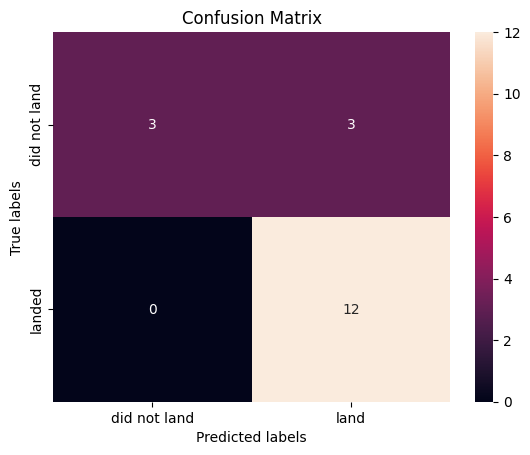

In [17]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [18]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Small parameter grid
parameters = {

    'kernel': ['linear'],

    'C': [1],

    'gamma': [0.1]

}

# Create SVM model
svm = SVC()

# GridSearchCV
svm_cv = GridSearchCV(

    svm,

    parameters,

    cv=3,

    n_jobs=-1

)

# Train
svm_cv.fit(X_train, Y_train)

# Results
print("Best Parameters:", svm_cv.best_params_)

print("Accuracy:", svm_cv.best_score_)

Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'linear'}
Accuracy: 0.8333333333333334


In [19]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1, 'gamma': 0.1, 'kernel': 'linear'}
accuracy : 0.8333333333333334


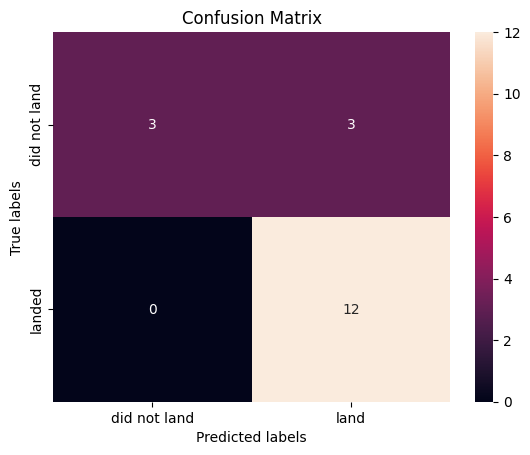

In [20]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# ============================================================
# Parameter Dictionary
# ============================================================

parameters = {

    'criterion': ['gini', 'entropy'],

    'splitter': ['best', 'random'],

    'max_depth': [2*n for n in range(1,10)],

    'max_features': ['sqrt'],

    'min_samples_leaf': [1, 2, 4],

    'min_samples_split': [2, 5, 10]

}

# ============================================================
# Create Decision Tree Model
# ============================================================

tree = DecisionTreeClassifier()

# ============================================================
# Create GridSearchCV Object
# ============================================================

tree_cv = GridSearchCV(

    estimator=tree,

    param_grid=parameters,

    cv=5,

    n_jobs=-1

)

# ============================================================
# Train Model
# ============================================================

tree_cv.fit(X_train, Y_train)

# ============================================================
# Best Parameters
# ============================================================

print(

    "Tuned hyperparameters (best parameters): ",

    tree_cv.best_params_

)

# ============================================================
# Best Accuracy
# ============================================================

print(

    "Accuracy : ",

    tree_cv.best_score_

)

Tuned hyperparameters (best parameters):  {'criterion': 'entropy', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'splitter': 'best'}
Accuracy :  0.8876190476190476


In [22]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'splitter': 'best'}
accuracy : 0.8876190476190476


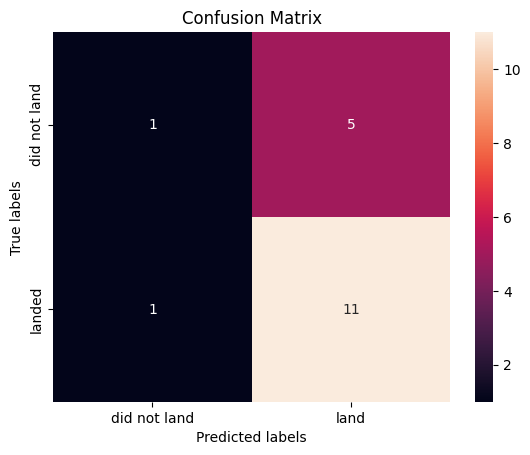

In [23]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# ============================================================
# Parameter Dictionary
# ============================================================

parameters = {

    'n_neighbors': [1,2,3,4,5,6,7,8,9,10],

    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],

    'p': [1,2]

}

# ============================================================
# Create KNN Model
# ============================================================

KNN = KNeighborsClassifier()

# ============================================================
# Create GridSearchCV Object
# ============================================================

knn_cv = GridSearchCV(

    estimator=KNN,

    param_grid=parameters,

    cv=5,

    n_jobs=-1

)

# ============================================================
# Train Model
# ============================================================

knn_cv.fit(X_train, Y_train)

# ============================================================
# Best Parameters
# ============================================================

print(

    "Tuned hyperparameters (best parameters): ",

    knn_cv.best_params_

)

# ============================================================
# Best Accuracy
# ============================================================

print(

    "Accuracy : ",

    knn_cv.best_score_

)

Tuned hyperparameters (best parameters):  {'algorithm': 'auto', 'n_neighbors': 1, 'p': 1}
Accuracy :  0.6542857142857142


In [25]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 1, 'p': 1}
accuracy : 0.6542857142857142


In [26]:
print("Test Accuracy :", knn_cv.score(X_test, Y_test))

Test Accuracy : 0.5555555555555556


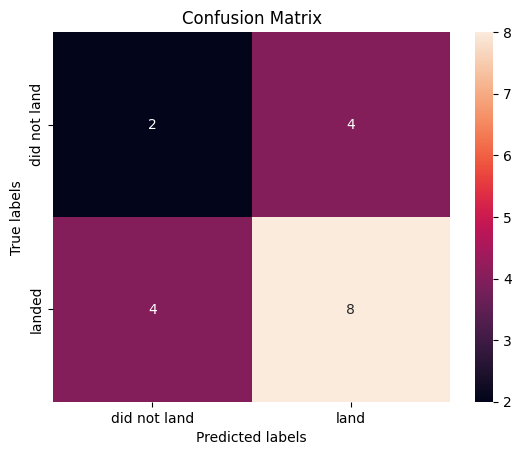

In [27]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [28]:
models = {

    "Logistic Regression": logreg_cv.score(X_test, Y_test),

    "SVM": svm_cv.score(X_test, Y_test),

    "Decision Tree": tree_cv.score(X_test, Y_test),

    "KNN": knn_cv.score(X_test, Y_test)

}

print(models)

{'Logistic Regression': 0.8333333333333334, 'SVM': 0.8333333333333334, 'Decision Tree': 0.6666666666666666, 'KNN': 0.5555555555555556}


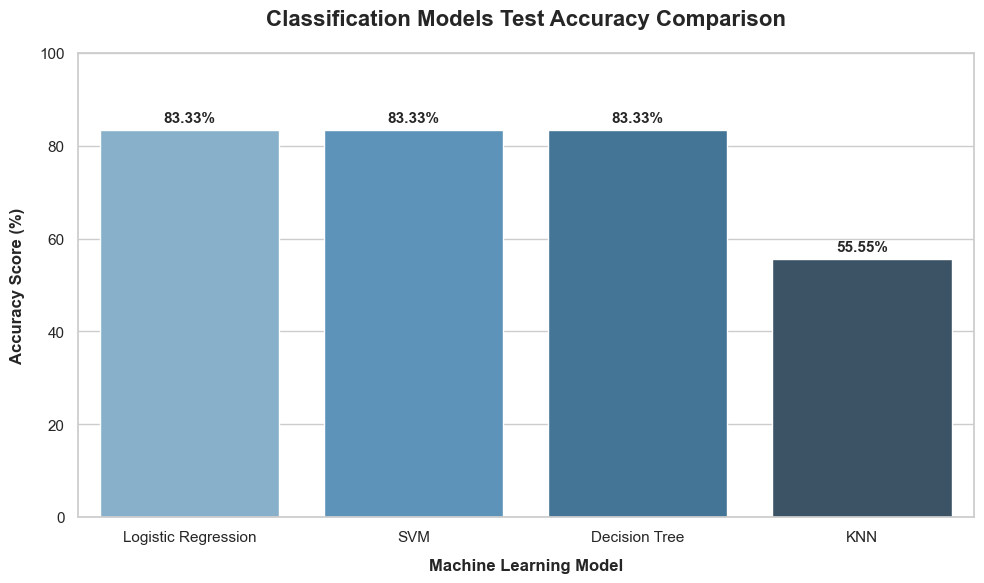

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the machine learning models and their test accuracy scores
models = ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN']
accuracy_scores = [83.33, 83.33, 83.33, 55.55]  # Values from the notebook

# 2. Set up the plotting environment and style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the bar chart
# Using a clean, professional color palette
ax = sns.barplot(x=models, y=accuracy_scores, palette="Blues_d", hue=models, legend=False)

# 4. Add data labels on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points', 
                fontsize=11, 
                fontweight='bold')

# 5. Customize titles and axis labels
plt.title('Classification Models Test Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Machine Learning Model', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Accuracy Score (%)', fontsize=12, fontweight='bold', labelpad=10)

# 6. Adjust visual limits for clean presentation
plt.ylim(0, 100)
plt.tight_layout()

# 7. Display the chart
plt.show()